# 02. Buildings & Address Analysis

This notebook explores the building stock of Nørrebro, focusing on the relationship between spatial footprints and official registry data (BBR/DAR).

**Data Sources:**
- **BBR (Attributes)**: `data/raw/bbr/norrebro_bbr_buildings.gpkg` - Contains year of construction, usage codes, floor counts.
- **DAR (Access)**: `data/raw/dar/norrebro_dar_adressepunkt.gpkg` - Contains entrance points (critical for routing).
- **Footprints (Viz)**: `data/processed/norrebro_building_footprints.gpkg` - Polygon geometries for context.

**Goals:**
1. **Data Quality**: Compare BBR points vs. Footprints. Are they aligned?
2. **Attributes Deep Dive**: Analyze building age, height, and usage.
3. **Land Use Map**: Classify buildings by usage (Residential vs Commercial vs Other).

In [2]:
import sys
from pathlib import Path

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import geopandas as gpd
from src.visualization import style
import contextily as ctx

style.apply_style()

## 1. Load Data

In [3]:
data_dir = project_root / "data"
bbr_path = data_dir / "raw" / "bbr" / "norrebro_bbr_buildings.gpkg"
dar_path = data_dir / "raw" / "dar" / "norrebro_dar_adressepunkt.gpkg"
footprint_path = data_dir / "processed" / "norrebro_building_footprints.gpkg"

gdf_bbr = gpd.read_file(bbr_path)
gdf_dar = gpd.read_file(dar_path)
gdf_footprints = gpd.read_file(footprint_path)

print(f"BBR Points: {len(gdf_bbr)}")
print(f"DAR Points: {len(gdf_dar)}")
print(f"Footprints: {len(gdf_footprints)}")

BBR Points: 3439
DAR Points: 11911
Footprints: 5914


## 2. Data Alignment: BBR vs Footprints
Visual check to see if BBR points (official attributes) fall inside the visual footprints.

/var/folders/j6/ft69qsf979gflgtqf862qt000000gs/T/ipykernel_46935/2745498414.py:18: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


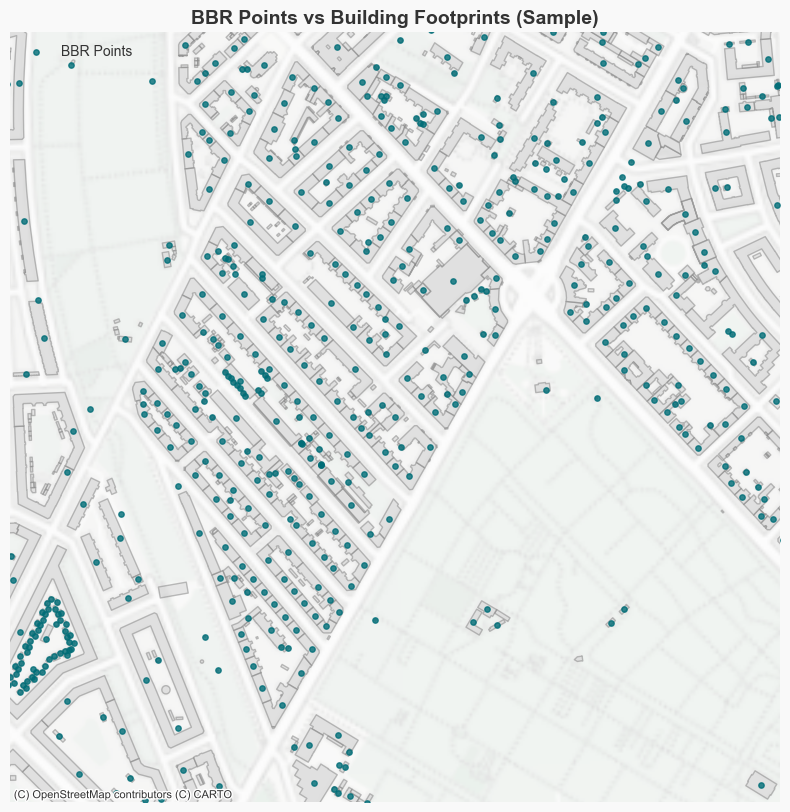

In [7]:
# Plotting a small sample area for clarity
sample_geom = gdf_bbr.geometry.iloc[0].buffer(400)  # 200m buffer around first building
xlim = (sample_geom.bounds[0], sample_geom.bounds[2])
ylim = (sample_geom.bounds[1], sample_geom.bounds[3])

fig, ax = plt.subplots(figsize=(10, 10))

# Footprints in background
gdf_footprints.plot(
    ax=ax, color="lightgrey", edgecolor="grey", alpha=0.5, label="Footprints"
)

# BBR Points
gdf_bbr.plot(
    ax=ax, color=style.PALETTE["brand"], markersize=15, label="BBR Points", alpha=0.8
)

ctx.add_basemap(
    ax, source=ctx.providers.CartoDB.PositronNoLabels, crs="EPSG:25832", alpha=0.8
)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_title("BBR Points vs Building Footprints (Sample)")
ax.legend()
plt.axis("off")
plt.show()

## 3. DAR Analysis (Access Points)
Filtering for actual entrances (`TD`, `TK`) vs road points (`V0`).

In [9]:
gdf_dar.columns

Index(['datafordelerOpdateringstid', 'datafordelerRowId',
       'datafordelerRowVersion', 'datafordelerRegisterImportSequenceNumber',
       'forretningshændelse', 'forretningsområde', 'forretningsproces',
       'id_namespace', 'id_lokalId', 'registreringFra', 'registreringsaktør',
       'registreringTil', 'status', 'virkningFra', 'virkningsaktør',
       'virkningTil', 'oprindelse_kilde', 'oprindelse_nøjagtighedsklasse',
       'oprindelse_registrering', 'oprindelse_tekniskStandard', 'position',
       'geometry'],
      dtype='str')

Technical Standards:
 oprindelse_tekniskStandard
V0    5749
TD    5639
TN     158
UF     134
V1      84
V2      75
V3      34
V8      17
V7       8
TA       7
TK       4
V9       2
Name: count, dtype: int64

Valid Entrances (TD/TK): 5643 (47.4%)


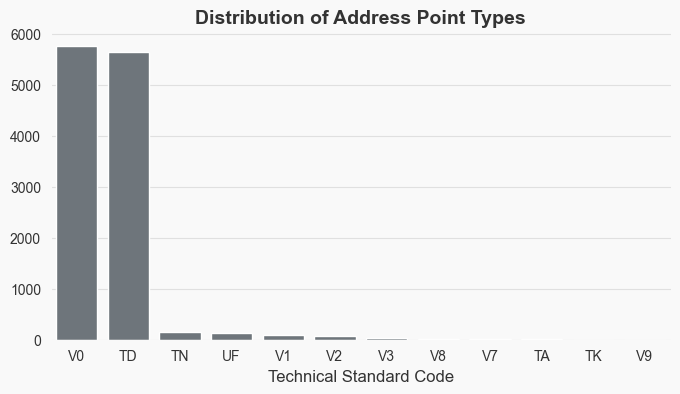

In [10]:
# Check technical standard distribution
if "oprindelse_tekniskStandard" in gdf_dar.columns:
    tech_std = gdf_dar["oprindelse_tekniskStandard"].value_counts()
    print("Technical Standards:\n", tech_std)

    # Filter for valid entrances (TD=Door, TK=Facade)
    valid_entrances = gdf_dar[gdf_dar["oprindelse_tekniskStandard"].isin(["TD", "TK"])]
    print(
        f"\nValid Entrances (TD/TK): {len(valid_entrances)} ({len(valid_entrances) / len(gdf_dar):.1%})"
    )

    # Visualize distribution
    plt.figure(figsize=(8, 4))
    sns.barplot(x=tech_std.index, y=tech_std.values, color=style.PALETTE["transport"])
    plt.title("Distribution of Address Point Types")
    plt.xlabel("Technical Standard Code")
    sns.despine()
    plt.show()

In [16]:
valid_entrances.oprindelse_tekniskStandard.value_counts()

oprindelse_tekniskStandard
TD    5639
TK       4
Name: count, dtype: int64

/var/folders/j6/ft69qsf979gflgtqf862qt000000gs/T/ipykernel_46935/112367415.py:25: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


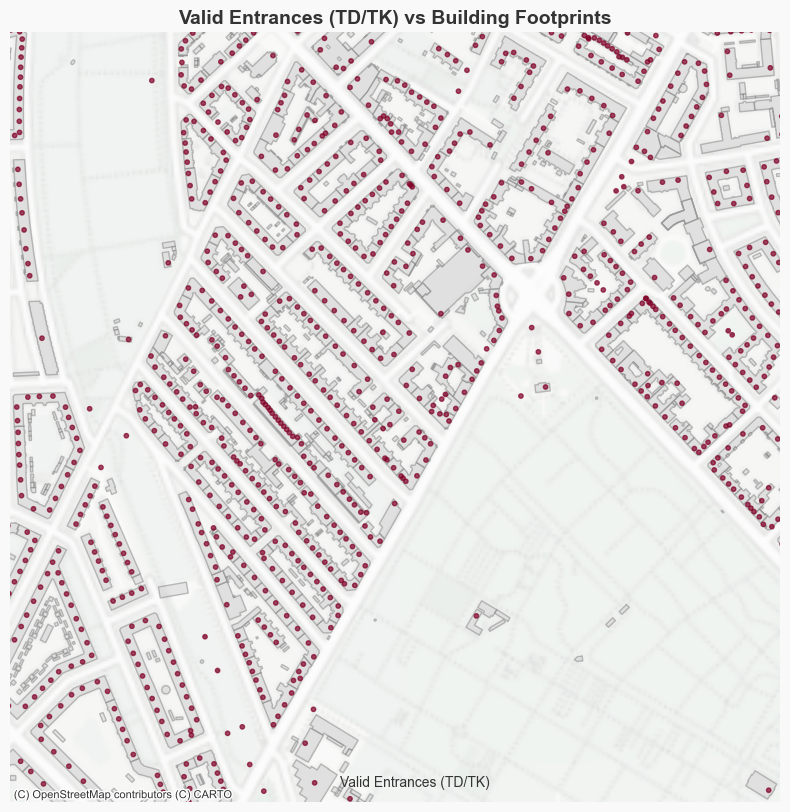

In [23]:
# Plot valid entrances on top of building footprints
fig, ax = plt.subplots(figsize=(10, 10))

# Footprints in background
gdf_footprints.plot(
    ax=ax, color="lightgrey", edgecolor="grey", alpha=0.5, label="Footprints"
)

# Valid entrances (TD/TK) on top
valid_entrances.plot(
    ax=ax,
    column="oprindelse_tekniskStandard",
    cmap="YlOrRd_r",
    markersize=10,
    label="Valid Entrances (TD/TK)",
    alpha=0.7,
)

ctx.add_basemap(
    ax, source=ctx.providers.CartoDB.PositronNoLabels, crs="EPSG:25832", alpha=0.8
)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_title("Valid Entrances (TD/TK) vs Building Footprints")
ax.legend()
plt.axis("off")
plt.show()

## 4. Building Attributes (BBR)
Analyzing construction year and usage.

In [25]:
gdf_bbr.columns

Index(['gml_id', 'forretningshændelse', 'forretningsområde',
       'forretningsproces', 'id_namespace', 'id_lokalId', 'kommunekode',
       'registreringFra', 'registreringsaktør', 'virkningFra',
       'virkningsaktør', 'status', 'byg007Bygningsnummer',
       'byg021BygningensAnvendelse', 'byg026Opførelsesår',
       'byg030Vandforsyning', 'byg031Afløbsforhold',
       'byg032YdervæggensMateriale', 'byg033Tagdækningsmateriale',
       'byg037KildeTilBygningensMaterialer', 'byg038SamletBygningsareal',
       'byg040BygningensSamledeErhvervsAreal', 'byg041BebyggetAreal',
       'byg053BygningsarealerKilde', 'byg054AntalEtager',
       'byg056Varmeinstallation', 'byg058SupplerendeVarme',
       'byg094Revisionsdato', 'byg133KildeTilKoordinatsæt',
       'byg134KvalitetAfKoordinatsæt',
       'byg135SupplerendeOplysningOmKoordinatsæt',
       'byg136PlaceringPåSøterritorie', 'byg406Koordinatsystem', 'jordstykke',
       'husnummer', 'grund', 'byg057Opvarmningsmiddel',
       'byg039Bygn

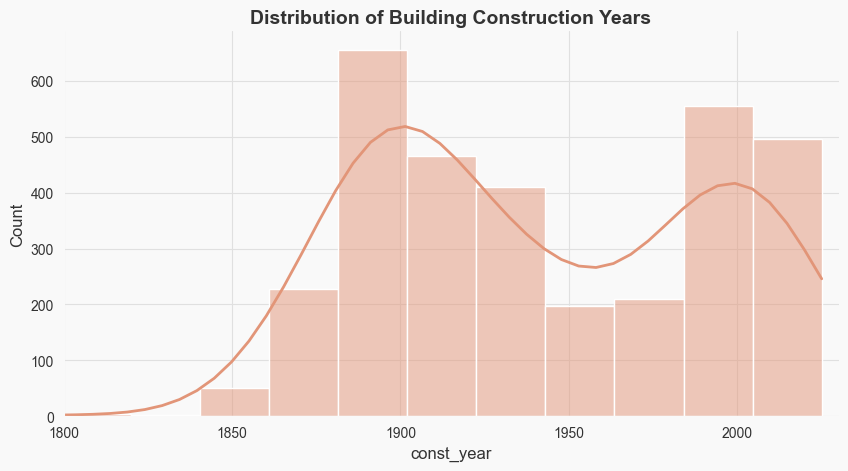

In [26]:
# Construction Year (byg026Opførelsesår)
year_col = "byg026Opførelsesår"
if year_col in gdf_bbr.columns:
    # Convert to numeric, handle errors
    gdf_bbr["const_year"] = pd.to_numeric(gdf_bbr[year_col], errors="coerce")

    plt.figure(figsize=(10, 5))
    sns.histplot(
        gdf_bbr["const_year"], bins=50, color=style.PALETTE["accent_warm"], kde=True
    )
    plt.title("Distribution of Building Construction Years")
    plt.xlim(1800, 2030)
    sns.despine()
    plt.show()

/var/folders/j6/ft69qsf979gflgtqf862qt000000gs/T/ipykernel_46935/1067574604.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=usage_counts.index, y=usage_counts.values, palette=colors)


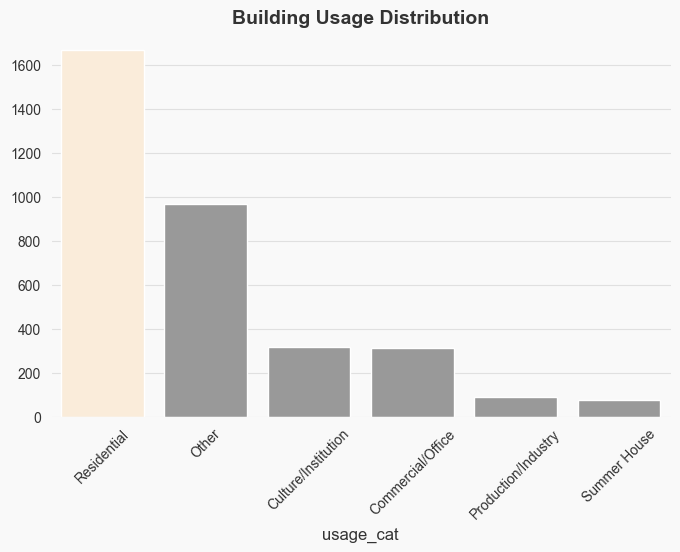

In [27]:
# Building Usage (byg021BygningensAnvendelse)
# 140 = Multi-dwelling residential
# map codes to categories
usage_col = "byg021BygningensAnvendelse"


def map_usage(code):
    code = int(code) if pd.notnull(code) else 0
    if 100 <= code < 200:
        return "Residential"
    if 200 <= code < 300:
        return "Production/Industry"
    if 300 <= code < 400:
        return "Commercial/Office"
    if 400 <= code < 500:
        return "Culture/Institution"
    if 500 <= code < 600:
        return "Summer House"
    return "Other"


if usage_col in gdf_bbr.columns:
    gdf_bbr["usage_cat"] = gdf_bbr[usage_col].apply(map_usage)

    usage_counts = gdf_bbr["usage_cat"].value_counts()

    plt.figure(figsize=(8, 5))
    colors = [style.get_categorical_color(c) for c in usage_counts.index]
    sns.barplot(x=usage_counts.index, y=usage_counts.values, palette=colors)
    plt.title("Building Usage Distribution")
    plt.xticks(rotation=45)
    sns.despine()
    plt.show()